Name:Rushi Rvairaj Gujarathi ||Roll no-17 ||PRN NO-1252090017

Assingment no:5

Predict the price of the uber ride from a given pickup point to the agreed drop -off location .Perform following tasks

1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error


2. Load the Dataset

In [ ]:
df = pd.read_csv("/content/uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


3. Dataset Overview

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(200000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB
None
         Unnamed: 0    fare_amount  pickup_longitude  pickup_latitude  \
count  2.000000e+05  200000.000000     200000.000000    200000.000000   
mean   2.771250e+07      11.359955        -72.527638        39.935885   
std    1.601382e+07       9.901776         11.437787

Data Pre-Processing

4.1 Handling Missing Values

In [ ]:
print(df.isnull().sum())
print(df.dropna(inplace=True))

Unnamed: 0           0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64
None


4.2 Remove Invalid Fare Values

In [ ]:
df = df[df['fare_amount'] > 0]


4.4 Convert Pickup Datetime

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month

df.drop(columns=['pickup_datetime'], inplace=True)

/tmp/ipython-input-1307205798.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
/tmp/ipython-input-1307205798.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['pickup_datetime'].dt.hour
/tmp/ipython-input-1307205798.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

2.Identify the outliers

In [ ]:
import pandas as pd


df=pd.read_csv("/content/uber.csv")
print(df)


        Unnamed: 0                            key  fare_amount  \
0         24238194    2015-05-07 19:52:06.0000003          7.5   
1         27835199    2009-07-17 20:04:56.0000002          7.7   
2         44984355   2009-08-24 21:45:00.00000061         12.9   
3         25894730    2009-06-26 08:22:21.0000001          5.3   
4         17610152  2014-08-28 17:47:00.000000188         16.0   
...            ...                            ...          ...   
199995    42598914   2012-10-28 10:49:00.00000053          3.0   
199996    16382965    2014-03-14 01:09:00.0000008          7.5   
199997    27804658   2009-06-29 00:42:00.00000078         30.9   
199998    20259894    2015-05-20 14:56:25.0000004         14.5   
199999    11951496   2010-05-15 04:08:00.00000076         14.1   

                pickup_datetime  pickup_longitude  pickup_latitude  \
0       2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1       2009-07-17 20:04:56 UTC        -73.994355        40.728225 

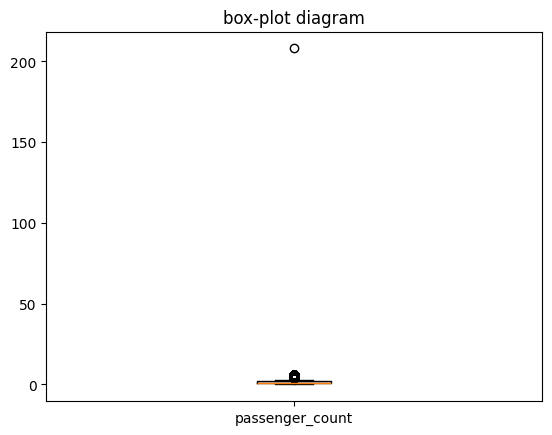

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot([df['passenger_count']] ,tick_labels=['passenger_count'])
plt.title("box-plot diagram")
plt.show()

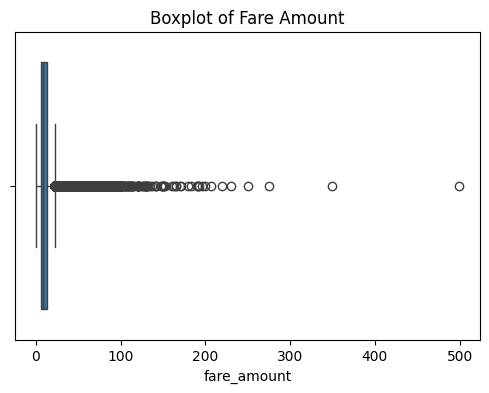

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Boxplot of Fare Amount")
plt.show()



In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['fare_amount'] >= Q1 - 1.5*IQR) &
        (df['fare_amount'] <= Q3 + 1.5*IQR)]


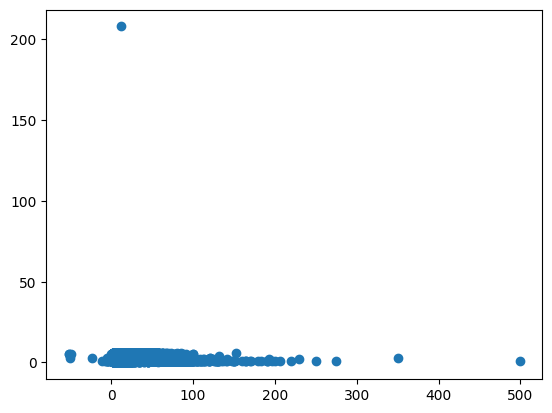

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['fare_amount'],df['passenger_count'])
plt.show()

6. Correlation Analysis

6.1 Pearson Correlation (Linear)

In [ ]:
df.corr()
df.corr(method='pearson')


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month
Unnamed: 0,1.000000,0.000042,0.000613,-0.001394,0.000939,-0.000701,0.002701,0.001583,0.000504,0.001668
fare_amount,0.000042,1.000000,-0.002155,0.005611,-0.005144,0.002969,0.017040,-0.000381,0.004460,0.024407
pickup_longitude,0.000613,-0.002155,1.000000,-0.805964,0.831901,-0.846613,-0.001057,0.004371,0.003091,-0.003226
pickup_latitude,-0.001394,0.005611,-0.805964,1.000000,-0.761610,0.674441,-0.001363,-0.005458,-0.006672,0.003526
dropoff_longitude,0.000939,-0.005144,0.831901,-0.761610,1.000000,-0.911822,-0.000160,0.004823,0.003934,-0.002721
dropoff_latitude,-0.000701,0.002969,-0.846613,0.674441,-0.911822,1.000000,-0.000324,-0.003963,-0.006124,0.002646
passenger_count,0.002701,0.017040,-0.001057,-0.001363,-0.000160,-0.000324,1.000000,0.013605,0.002768,0.008829
hour,0.001583,-0.000381,0.004371,-0.005458,0.004823,-0.003963,0.013605,1.000000,0.005070,-0.002889
day,0.000504,0.004460,0.003091,-0.006672,0.003934,-0.006124,0.002768,0.005070,1.000000,-0.016055
month,0.001668,0.024407,-0.003226,0.003526,-0.002721,0.002646,0.008829,-0.002889,-0.016055,1.000000


6.2 Spearman Correlation (Monotonic)

In [ ]:
df.corr(method='spearman')

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month
Unnamed: 0,1.000000,0.000806,0.004530,0.005040,0.007799,0.004149,0.003927,0.001103,0.000504,0.001785
fare_amount,0.000806,1.000000,-0.049840,-0.065165,0.003316,-0.060461,0.023383,0.012181,0.004225,0.025078
pickup_longitude,0.004530,-0.049840,1.000000,0.573564,0.499400,0.316943,-0.019774,-0.007528,-0.004362,-0.003777
pickup_latitude,0.005040,-0.065165,0.573564,1.000000,0.294038,0.607174,-0.015312,0.008764,-0.002033,0.000321
dropoff_longitude,0.007799,0.003316,0.499400,0.294038,1.000000,0.534069,-0.019331,-0.020655,-0.009302,-0.003135
dropoff_latitude,0.004149,-0.060461,0.316943,0.607174,0.534069,1.000000,-0.011921,0.002663,-0.006221,-0.000640
passenger_count,0.003927,0.023383,-0.019774,-0.015312,-0.019331,-0.011921,1.000000,0.038300,0.001047,0.008818
hour,0.001103,0.012181,-0.007528,0.008764,-0.020655,0.002663,0.038300,1.000000,0.006151,-0.001674
day,0.000504,0.004225,-0.004362,-0.002033,-0.009302,-0.006221,0.001047,0.006151,1.000000,-0.015814
month,0.001785,0.025078,-0.003777,0.000321,-0.003135,-0.000640,0.008818,-0.001674,-0.015814,1.000000


6.3 Kendall Correlation (Rank-based)

In [ ]:
df.corr(method='kendall')

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month
Unnamed: 0,1.000000,0.000539,0.003019,0.003357,0.005200,0.002763,0.003047,0.000752,0.000340,0.001235
fare_amount,0.000539,1.000000,-0.034180,-0.044447,0.001788,-0.041124,0.018349,0.008562,0.002900,0.017624
pickup_longitude,0.003019,-0.034180,1.000000,0.433218,0.351832,0.222866,-0.015350,-0.006136,-0.002956,-0.002622
pickup_latitude,0.003357,-0.044447,0.433218,1.000000,0.207847,0.438225,-0.011879,0.005577,-0.001379,0.000223
dropoff_longitude,0.005200,0.001788,0.351832,0.207847,1.000000,0.407589,-0.014972,-0.014016,-0.006297,-0.002177
dropoff_latitude,0.002763,-0.041124,0.222866,0.438225,0.407589,1.000000,-0.009246,0.002653,-0.004227,-0.000444
passenger_count,0.003047,0.018349,-0.015350,-0.011879,-0.014972,-0.009246,1.000000,0.030399,0.000822,0.007119
hour,0.000752,0.008562,-0.006136,0.005577,-0.014016,0.002653,0.030399,1.000000,0.004264,-0.001188
day,0.000340,0.002900,-0.002956,-0.001379,-0.006297,-0.004227,0.000822,0.004264,1.000000,-0.011132
month,0.001235,0.017624,-0.002622,0.000223,-0.002177,-0.000444,0.007119,-0.001188,-0.011132,1.000000


6.4 Correlation Heatmap

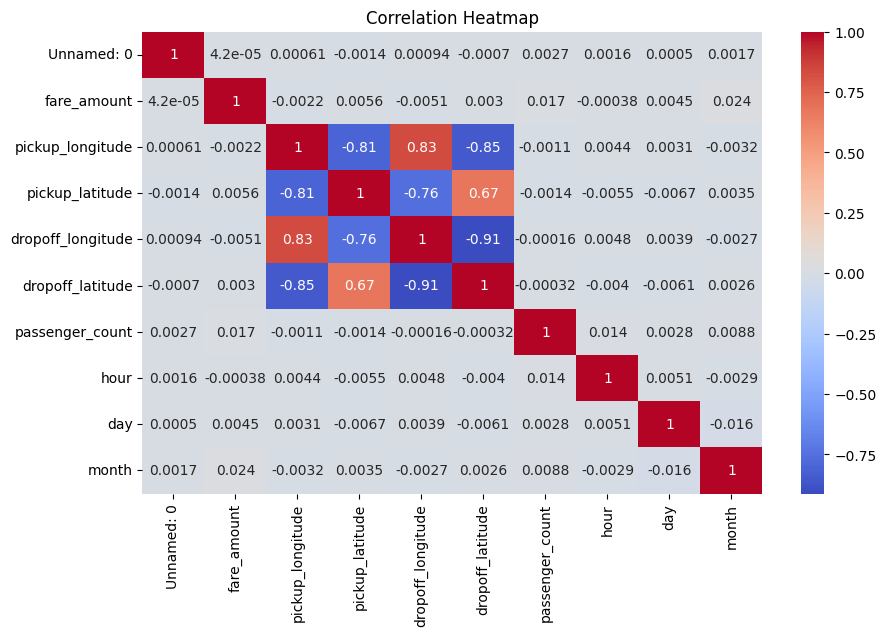

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


🔹 7. Feature Selection & Train-Test Split

In [ ]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


8. Model Implementation

8.1 Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print(y_pred_lr)

[8.37851728 8.49517165 8.58104403 ... 8.25606723 8.49629412 8.48484552]


8.2 Ridge Regression

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
print(y_pred_ridge)

[8.3785174  8.49517157 8.5810435  ... 8.25606736 8.49629415 8.48484557]


8.3 Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
print(y_pred_lasso)

[8.40307906 8.45828785 8.4330106  ... 8.29044227 8.49363438 8.4771146 ]


9. Model Evaluation

In [ ]:
def evaluate_model(y_test, y_pred, model_name):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{model_name}")
    print("R2 Score :", r2)
    print("RMSE :", rmse)
    print("-"*30)
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
R2 Score : 0.0007029117046019051
RMSE : 3.4757601087503507
------------------------------
Ridge Regression
R2 Score : 0.0007029120433769132
RMSE : 3.4757601081611864
------------------------------
Lasso Regression
R2 Score : 0.0005262889608425025
RMSE : 3.476067260232366
------------------------------


Linear Regression

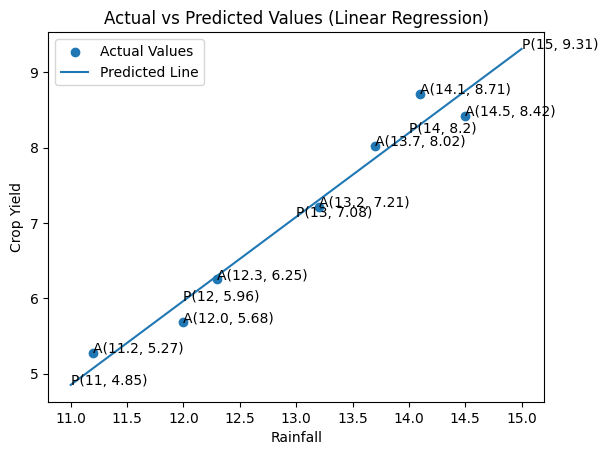

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rainfall = [[12.3], [13.7], [14.5], [11.2], [13.2], [14.1], [12.0]]
crop_yield = [[6.25], [8.02], [8.42], [5.27], [7.21], [8.71], [5.68]]

model = LinearRegression()
model.fit(rainfall, crop_yield)

x_values = [[11], [12], [13], [14], [15]]
y_pred = model.predict(x_values)


plt.scatter(rainfall, crop_yield, label="Actual Values")


for i in range(len(rainfall)):
    plt.text(rainfall[i][0], crop_yield[i][0],
             f"A({rainfall[i][0]}, {crop_yield[i][0]})")


plt.plot(x_values, y_pred, label="Predicted Line")


for i in range(len(x_values)):
    plt.text(x_values[i][0], y_pred[i][0],
             f"P({x_values[i][0]}, {round(y_pred[i][0],2)})")


plt.xlabel("Rainfall")
plt.ylabel("Crop Yield")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.legend()


plt.show()





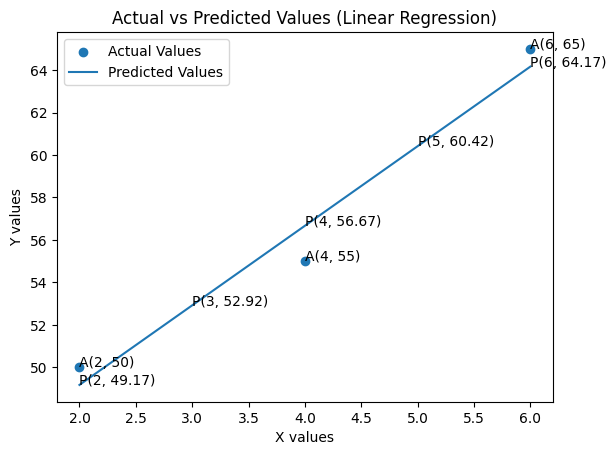

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = [[2], [4], [6]]
y = [[50], [55], [65]]


model = LinearRegression()
model.fit(x, y)


x_line = [[2], [3], [4], [5], [6]]
y_line = model.predict(x_line)


plt.scatter(x, y, label="Actual Values")


for i in range(len(x)):
    plt.text(x[i][0], y[i][0], f"A({x[i][0]}, {y[i][0]})")

plt.plot(x_line, y_line, label="Predicted Values")


for i in range(len(x_line)):
    plt.text(x_line[i][0], y_line[i][0],
             f"P({x_line[i][0]}, {round(y_line[i][0], 2)})")


plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.legend()


plt.show()


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report


actual = [1, 0, 0, 1, 0, 0, 1, 0, 0, 1]


predicted = [1, 0, 0, 1, 0, 0, 0, 1, 0, 0]

matrix = confusion_matrix(actual, predicted, labels=[1, 0])
print("Confusion Matrix:\n", matrix)


tp, fn, fp, tn = confusion_matrix(
    actual, predicted, labels=[1, 0]
).ravel()

print("Outcome values:")
print("TP:", tp)
print("FN:", fn)
print("FP:", fp)
print("TN:", tn)


report = classification_report(actual, predicted, labels=[1, 0])
print("Classification Report:\n", report)

Confusion Matrix:
 [[2 2]
 [1 5]]
Outcome values:
TP: 2
FN: 2
FP: 1
TN: 5
Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.50      0.57         4
           0       0.71      0.83      0.77         6

    accuracy                           0.70        10
   macro avg       0.69      0.67      0.67        10
weighted avg       0.70      0.70      0.69        10

